# EfficientNet-B0 Partial Unfreeze + Penalty Regularization

## Motivation
ResNet18 (11M params) overfits heavily on this dataset (~5k samples, 779 melanoma). EfficientNet-B0 has ~5.3M params and we further reduce active parameters by only unfreezing the last 3 blocks of the backbone, leaving the rest frozen.

## Architecture
EfficientNet-B0 `model.features` has 9 children:
- `[0]` stem conv
- `[1-7]` MBConv blocks
- `[8]` head conv

`unfreeze_last_n_blocks=3` trains only blocks 6, 7, and head conv + classifier.

## Lambda Sweep
| Run | l1_lambda | l2_lambda | Purpose |
|-----|-----------|-----------|--------|
| 0   | 0         | 0         | Baseline (no penalty) |
| 1   | 0         | 1e-4      | Mild L2 |
| 2   | 0         | 1e-3      | Moderate L2 |
| 3   | 1e-4      | 0         | Mild L1 |
| 4   | 1e-3      | 0         | Moderate L1 |

In [30]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import fbeta_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataloader import get_dataloaders
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [17]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [18]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Lambda Sweep

In [19]:
all_results = {}

In [20]:
# --- Baseline (no penalty) ---
num_epochs = 20
run_label = 'Baseline'
l1_lambda = 0.0
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: Baseline (l1=0.0, l2=0.0) ===


  Epoch [1/20] | Train Loss: 0.9084, F2: 0.5521 | Val Loss: 0.8232, F2: 0.5911 | LR: 1.00e-04
    -> New best val F2: 0.5911


  Epoch [2/20] | Train Loss: 0.6885, F2: 0.6518 | Val Loss: 0.7861, F2: 0.6188 | LR: 1.00e-04
    -> New best val F2: 0.6188


  Epoch [3/20] | Train Loss: 0.5911, F2: 0.6949 | Val Loss: 0.8116, F2: 0.6299 | LR: 1.00e-04
    -> New best val F2: 0.6299


  Epoch [4/20] | Train Loss: 0.4901, F2: 0.7462 | Val Loss: 0.9104, F2: 0.6211 | LR: 1.00e-04


...

  Epoch [16/20] | Train Loss: 0.1283, F2: 0.9353 | Val Loss: 1.1197, F2: 0.6385 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.1104, F2: 0.9468 | Val Loss: 1.3083, F2: 0.6124 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.1133, F2: 0.9428 | Val Loss: 1.2849, F2: 0.6294 | LR: 2.50e-05


  Epoch [19/20] | Train Loss: 0.0965, F2: 0.9506 | Val Loss: 1.3858, F2: 0.6119 | LR: 2.50e-05


  Epoch [20/20] | Train Loss: 0.1003, F2: 0.9501 | Val Loss: 1.3169, F2: 0.6374 | LR: 2.50e-05
Best val F2 for Baseline: 0.6487


In [21]:
# --- L2=1e-3 ---
num_epochs = 20
run_label = 'L2=1e-3'
l1_lambda = 0.0
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L2=1e-3 (l1=0.0, l2=0.001) ===


  Epoch [1/20] | Train Loss: 1.0304, F2: 0.5228 | Val Loss: 0.9513, F2: 0.5596 | LR: 1.00e-04
    -> New best val F2: 0.5596


  Epoch [2/20] | Train Loss: 0.8861, F2: 0.5711 | Val Loss: 0.8891, F2: 0.5798 | LR: 1.00e-04
    -> New best val F2: 0.5798


  Epoch [3/20] | Train Loss: 0.8381, F2: 0.5799 | Val Loss: 0.8592, F2: 0.5884 | LR: 1.00e-04
    -> New best val F2: 0.5884


  Epoch [4/20] | Train Loss: 0.7921, F2: 0.6017 | Val Loss: 0.8398, F2: 0.5954 | LR: 1.00e-04
    -> New best val F2: 0.5954


...

  Epoch [16/20] | Train Loss: 0.5756, F2: 0.7171 | Val Loss: 0.8406, F2: 0.5939 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.5560, F2: 0.7326 | Val Loss: 0.8381, F2: 0.5833 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.5449, F2: 0.7331 | Val Loss: 0.8113, F2: 0.6076 | LR: 2.50e-05


  Epoch [19/20] | Train Loss: 0.5242, F2: 0.7472 | Val Loss: 0.8189, F2: 0.5997 | LR: 2.50e-05


  Epoch [20/20] | Train Loss: 0.5491, F2: 0.7301 | Val Loss: 0.8189, F2: 0.5953 | LR: 2.50e-05
Best val F2 for L2=1e-3: 0.6201


In [22]:
# --- L1=1e-3 ---
num_epochs = 20
run_label = 'L1=1e-3'
l1_lambda = 1e-3
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3 (l1=0.001, l2=0.0) ===


  Epoch [1/20] | Train Loss: 1.0656, F2: 0.5138 | Val Loss: 0.9910, F2: 0.5530 | LR: 1.00e-04
    -> New best val F2: 0.5530


  Epoch [2/20] | Train Loss: 0.9243, F2: 0.5607 | Val Loss: 0.9209, F2: 0.5771 | LR: 1.00e-04
    -> New best val F2: 0.5771


  Epoch [3/20] | Train Loss: 0.8724, F2: 0.5707 | Val Loss: 0.8818, F2: 0.5902 | LR: 1.00e-04
    -> New best val F2: 0.5902


  Epoch [4/20] | Train Loss: 0.8290, F2: 0.5901 | Val Loss: 0.8618, F2: 0.5856 | LR: 1.00e-04


...

  Epoch [16/20] | Train Loss: 0.7139, F2: 0.6391 | Val Loss: 0.8279, F2: 0.6066 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.6946, F2: 0.6612 | Val Loss: 0.8009, F2: 0.6186 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.6899, F2: 0.6560 | Val Loss: 0.8172, F2: 0.6018 | LR: 2.50e-05


  Epoch [19/20] | Train Loss: 0.6685, F2: 0.6689 | Val Loss: 0.7964, F2: 0.6226 | LR: 2.50e-05
    -> New best val F2: 0.6226


  Epoch [20/20] | Train Loss: 0.6867, F2: 0.6609 | Val Loss: 0.7854, F2: 0.6282 | LR: 2.50e-05
    -> New best val F2: 0.6282
Best val F2 for L1=1e-3: 0.6282


In [23]:
# --- L1=1e-3 and L2=1e-3 ---
num_epochs = 40
run_label = 'L1=1e-3, L2=1e-3'
l1_lambda = 1e-3
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3, L2=1e-3 (l1=0.001, l2=0.001) ===


  Epoch [1/40] | Train Loss: 1.0707, F2: 0.5107 | Val Loss: 0.9982, F2: 0.5518 | LR: 1.00e-04
    -> New best val F2: 0.5518


  Epoch [2/40] | Train Loss: 0.9312, F2: 0.5578 | Val Loss: 0.9279, F2: 0.5724 | LR: 1.00e-04
    -> New best val F2: 0.5724


  Epoch [3/40] | Train Loss: 0.8790, F2: 0.5681 | Val Loss: 0.8878, F2: 0.5892 | LR: 1.00e-04
    -> New best val F2: 0.5892


  Epoch [4/40] | Train Loss: 0.8354, F2: 0.5882 | Val Loss: 0.8674, F2: 0.5866 | LR: 1.00e-04


...

  Epoch [36/40] | Train Loss: 0.6074, F2: 0.7102 | Val Loss: 0.8112, F2: 0.6176 | LR: 6.25e-06


  Epoch [37/40] | Train Loss: 0.6122, F2: 0.6979 | Val Loss: 0.8034, F2: 0.6163 | LR: 6.25e-06


  Epoch [38/40] | Train Loss: 0.5985, F2: 0.7185 | Val Loss: 0.7973, F2: 0.6266 | LR: 6.25e-06


  Epoch [39/40] | Train Loss: 0.6037, F2: 0.7103 | Val Loss: 0.7880, F2: 0.6313 | LR: 3.13e-06


  Epoch [40/40] | Train Loss: 0.6033, F2: 0.7116 | Val Loss: 0.7902, F2: 0.6226 | LR: 3.13e-06
Best val F2 for L1=1e-3, L2=1e-3: 0.6381


## Compare Overfitting: Train vs Val F2 Gap

In [24]:
print(f"{'Run':<12} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'Gap (T-V)':>9}")
print('-' * 70)
for run_label, result in all_results.items():
    h = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2 = h['val_f2'][-1]
    gap = final_train_f2 - final_val_f2
    print(f"{run_label:<12} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>9.4f}")

Run          | Best Val F2 | Final Train F2 | Final Val F2 | Gap (T-V)
----------------------------------------------------------------------
Baseline     |      0.6487 |         0.9501 |       0.6374 |    0.3127
L2=1e-3      |      0.6201 |         0.7301 |       0.5953 |    0.1348
L1=1e-3      |      0.6282 |         0.6609 |       0.6282 |    0.0327
L1=1e-3, L2=1e-3 |      0.6381 |         0.7116 |       0.6226 |    0.0890


## Compare Overfitting: Train vs Val Loss Gap

In [25]:
print(f"{'Run':<12} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print("-" * 62)
for run_label, result in all_results.items():
    h = result["history"]
    final_train_loss = h["train_loss"][-1]
    final_val_loss = h["val_loss"][-1]
    gap = final_val_loss - final_train_loss
    print(f"{run_label:<12} | {final_train_loss:>15.4f} | {final_val_loss:>14.4f} | {gap:>14.4f}")


Run          | Final Train Loss | Final Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
Baseline     |          0.1003 |         1.3169 |         1.2166
L2=1e-3      |          0.5491 |         0.8189 |         0.2697
L1=1e-3      |          0.6867 |         0.7854 |         0.0987
L1=1e-3, L2=1e-3 |          0.6033 |         0.7902 |         0.1869


## Compare Test Loss, Recall and F2 for all Runs

In [28]:
from sklearn.metrics import recall_score, precision_score

print(f"{'Run':<12} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test Prec':>10} | {'Test F2':>9}")
print('-' * 62)

for run_label, result in all_results.items():
    eval_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss = 0.0
    total_samples = 0
    all_labels_test = []
    all_probs_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs = eval_model(images)
            loss = criterion_eval(outputs, labels_dev)
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs_test.extend(probs.cpu().numpy())
            all_labels_test.extend(labels.numpy())

    test_loss = running_loss / total_samples

    val_probs_run, val_labels_run = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = eval_model(images.to(device))
            probs = torch.sigmoid(outputs).squeeze(1)
            val_probs_run.extend(probs.cpu().numpy())
            val_labels_run.extend(labels.numpy())

    thresholds = np.arange(0.01, 0.9, 0.01)
    f2_scores = [fbeta_score(val_labels_run, (np.array(val_probs_run) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f2_scores)]

    preds = (np.array(all_probs_test) >= best_threshold).astype(int)
    test_f2 = fbeta_score(all_labels_test, preds, beta=2, pos_label=1, zero_division=0)
    test_recall = recall_score(all_labels_test, preds, pos_label=1, zero_division=0)
    test_precision = precision_score(all_labels_test, preds, pos_label=1, zero_division=0)

    print(f"{run_label:<12} | {test_loss:>9.4f} | {test_recall:>11.4f} | {test_precision:>10.4f} | {test_f2:>9.4f}")

## Training Curves

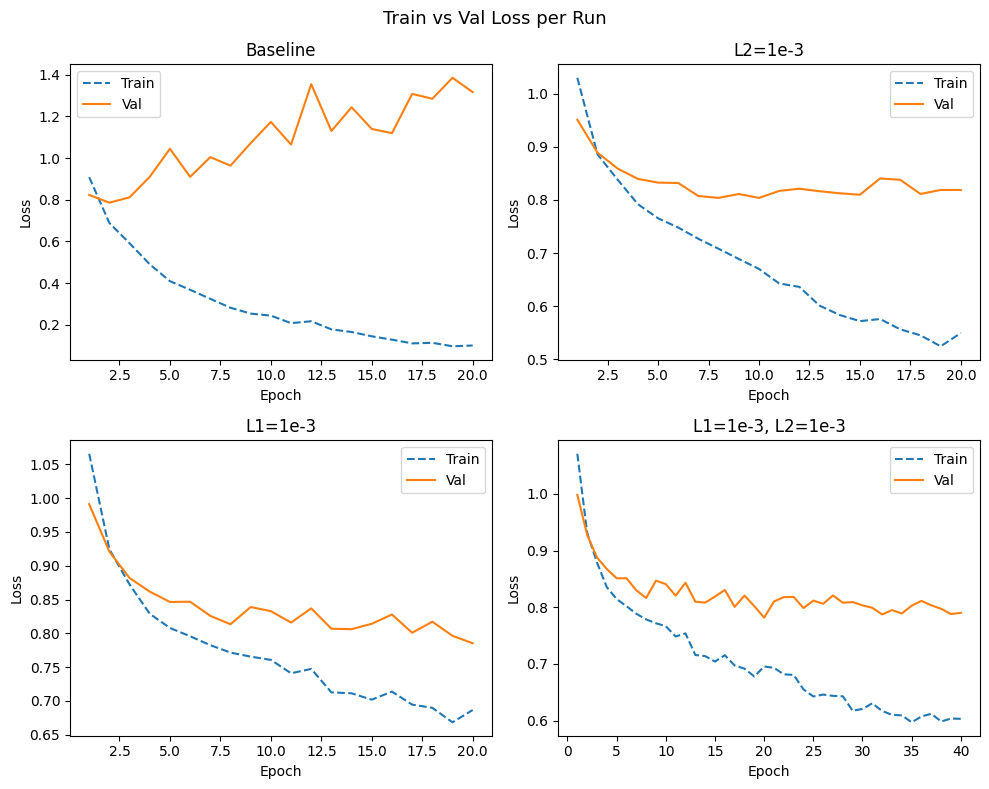

In [31]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_loss'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val Loss per Run', fontsize=13)
plt.tight_layout()
plt.show()

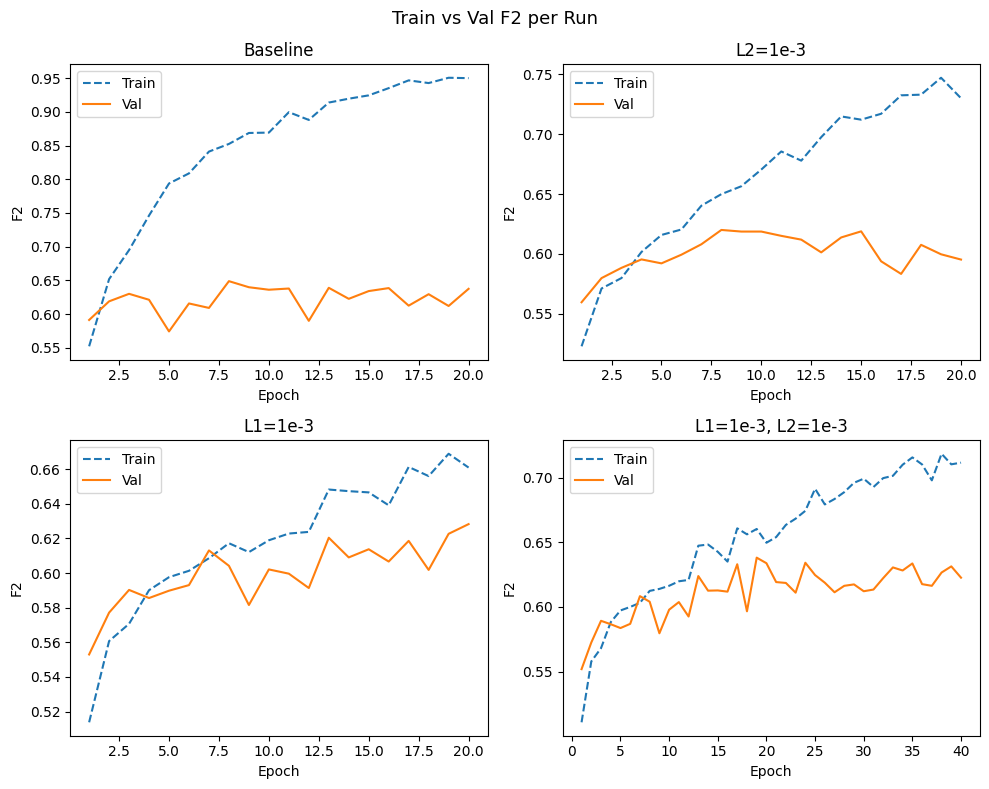

In [32]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_f2']) + 1)
    ax.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_f2'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F2')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val F2 per Run', fontsize=13)
plt.tight_layout()
plt.show()

## Save & Evaluate Best Run

In [ ]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

torch.save(best_model.state_dict(), 'models/efficientnet_b0_partial_unfreeze_penalty_best.pth')
print('Saved to models/efficientnet_b0_partial_unfreeze_penalty_best.pth')

Best run: Baseline (val F2 = 0.7727)
Saved to models/efficientnet_b0_partial_unfreeze_penalty_best.pth


## Threshold Tuning

In [ ]:
best_model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = best_model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [
    fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.53 | Val F2: 0.7754


## Test Set Evaluation

In [ ]:
best_model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[935  71]
 [ 42 125]]

              precision    recall  f1-score   support

           0     0.9570    0.9294    0.9430      1006
           1     0.6378    0.7485    0.6887       167

    accuracy                         0.9037      1173
   macro avg     0.7974    0.8390    0.8159      1173
weighted avg     0.9116    0.9037    0.9068      1173



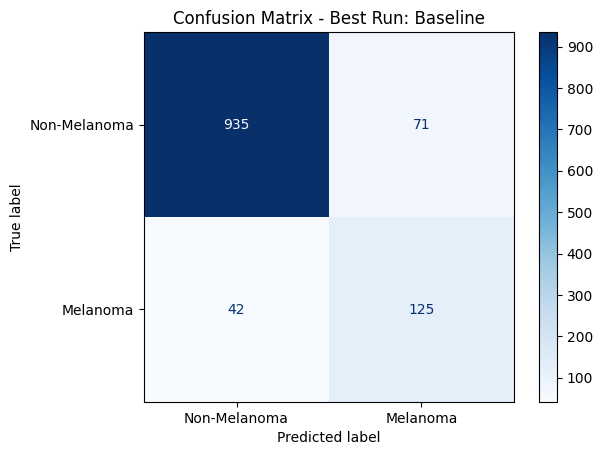

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Best Run: {best_run_label}')
plt.show()